## TF-IDF(Axis 1) + MLP(Axis 2)

In [1]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from pubmed_loader import PubMedQAData
from preprocessing import preprocess_tfidf
from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, training_curves, get_errors_by_type

In [2]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

In [3]:
def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

In [4]:
set_all_seeds()

All seeds set to 11


### 1. Data Loading & Preprocessing

In [5]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set, use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set, use_mesh=True)

print(f"train: {len(train_texts)} samples")
print(f"dev:   {len(dev_texts)}   samples")
print(f"test:  {len(test_texts)}  samples")

train: 450 samples
dev:   50   samples
test:  500  samples


In [7]:
print("Train:", np.bincount(train_labels))
print("Dev: ", np.bincount(dev_labels))
print("Test: ", np.bincount(test_labels))

Train: [249 152  49]
Dev:  [27 17  6]
Test:  [276 169  55]


In [8]:
combined_texts = train_texts + dev_texts
combined_labels = train_labels + dev_labels

### 2. TF-IDF Vectorisation

In [9]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

In [10]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=med_stopwords,
    max_features=5000,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_texts)
X_dev = vectorizer.transform(dev_texts)
X_test = vectorizer.transform(test_texts)

INPUT_DIM = X_train.shape[1]
print(f"TF-IDF input dim: {INPUT_DIM}")

TF-IDF input dim: 5000


#### 2.1 Dimensionality Reduction: LSA (TruncatedSVD)

In [13]:
from sklearn.decomposition import TruncatedSVD

In [15]:
# fit a full SVD to find the 90% variance threshold
svd_analysis = TruncatedSVD(n_components=500, random_state=RANDOM_SEED)
svd_analysis.fit(X_train)

BEST_N = int(np.searchsorted(np.cumsum(svd_analysis.explained_variance_ratio_), 0.80) + 1)
print(f"Components needed to explain 80% variance: {BEST_N}")

Components needed to explain 80% variance: 296


In [37]:
lsa = TruncatedSVD(n_components=BEST_N, random_state=RANDOM_SEED)

X_train_lsa = lsa.fit_transform(X_train)
X_dev_lsa = lsa.transform(X_dev)
X_test_lsa = lsa.transform(X_test)
print(f"Shape: {X_train_lsa.shape}")
INPUT_DIM_LSA = X_train_lsa.shape[1]

Shape: (450, 296)


### 3. MLP

Wrap datases in DataLoader objects

In [21]:
def convert_to_tensor(X, labels):
    # Convert sparse matrix & label list to TensorDataset.
    # both sparse matrix and numpy array
    if hasattr(X, 'toarray'):
        X = X.toarray()
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(X, y)

In [19]:
BATCH_SIZE = 64

train_dataset = convert_to_tensor(X_train, train_labels)
dev_dataset = convert_to_tensor(X_dev, dev_labels)
test_dataset = convert_to_tensor(X_test,test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [20]:
train_dataset_lsa = convert_to_tensor(X_train_lsa, train_labels)
dev_dataset_lsa = convert_to_tensor(X_dev_lsa, dev_labels)
test_dataset_lsa = convert_to_tensor(X_test_lsa, test_labels)

train_loader_lsa = DataLoader(train_dataset_lsa, batch_size=BATCH_SIZE, shuffle=True)
dev_loader_lsa = DataLoader(dev_dataset_lsa, batch_size=BATCH_SIZE)
test_loader_lsa = DataLoader(test_dataset_lsa, batch_size=BATCH_SIZE)

MLP Architecture

In [22]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )
    
    def forward(self, x):
        return self.network(x)

Training

In [23]:
# Training Loop
def train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate, class_weights=None):
    # If weights is not None, apply them to the loss function
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(next(model.parameters()).device))
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses = []
    all_dev_losses = []

    # Track the best model
    best_dev_loss = float('inf')
    best_state = None

    for e in range(num_epochs):
        total_correct = 0
        total_trained = 0
        train_losses = []

        model.train()

        for batch_X, batch_y in train_loader:
            # Reset the optimizer
            optimizer.zero_grad()

            # Use the model to perform forward inference on the input data.
            # This will run the forward() function.
            output = model(batch_X)

            # Compute the loss for the current batch of data
            batch_loss = loss_fn(output, batch_y)

            # Perform back propagation to compute the gradients with respect to each weight
            batch_loss.backward()

            # Update the weights using the compute gradients
            optimizer.step()

            # Record the loss from this sample to keep track of progress.
            train_losses.append(batch_loss.item())

            # Count correct labels so we can compute accuracy on the training set
            predicted_labels = output.argmax(1)
            total_correct += (predicted_labels == batch_y).sum().item()
            total_trained += batch_y.size(0)

        train_accuracy = total_correct/total_trained*100
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_accuracy))
        
        all_train_losses.append(np.mean(train_losses))

        # Switch model to evaluation mode
        model.eval()
        total_correct = 0
        total_trained = 0
        dev_losses = []

        with torch.no_grad():
            for dev_input_ids, dev_labels in dev_loader:
                dev_output = model(dev_input_ids)
                
                dev_loss = loss_fn(dev_output, dev_labels)

                dev_losses.append(dev_loss.item())
                
                predicted_labels = dev_output.argmax(1)
                total_correct += (predicted_labels == dev_labels).sum().item()
                total_trained += dev_labels.size(0)
        
        dev_accuracy = total_correct/total_trained*100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(np.mean(dev_losses))
        
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Validation Loss: {:.4f}".format(np.mean(dev_losses)),
              "Validation Accuracy: {:.4f}%".format(dev_accuracy))

        # Save the best model & Early Stopping
        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    # Restore the optimal weight and then return
    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    
    return model, all_train_losses, all_dev_losses

In [26]:
set_all_seeds()

num_epochs = 15
learning_rate = 0.001

model = MLP(input_dim=INPUT_DIM)
trained_model, train_losses, dev_losses = train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate)


All seeds set to 11
Epoch: 1/15 Training Loss: 1.0756 Training Accuracy: 33.7778%
Epoch: 1/15 Validation Loss: 1.0665 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0665)
Epoch: 2/15 Training Loss: 1.0607 Training Accuracy: 49.1111%
Epoch: 2/15 Validation Loss: 1.0407 Validation Accuracy: 52.0000%
Best model saved (validation_loss=1.0407)
Epoch: 3/15 Training Loss: 1.0041 Training Accuracy: 60.4444%
Epoch: 3/15 Validation Loss: 1.0084 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0084)
Epoch: 4/15 Training Loss: 0.9195 Training Accuracy: 55.7778%
Epoch: 4/15 Validation Loss: 0.9723 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9723)
Epoch: 5/15 Training Loss: 0.8776 Training Accuracy: 55.3333%
Epoch: 5/15 Validation Loss: 0.9649 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9649)
Epoch: 6/15 Training Loss: 0.8710 Training Accuracy: 55.3333%
Epoch: 6/15 Validation Loss: 0.9757 Validation Accuracy: 54.0000%
Ep

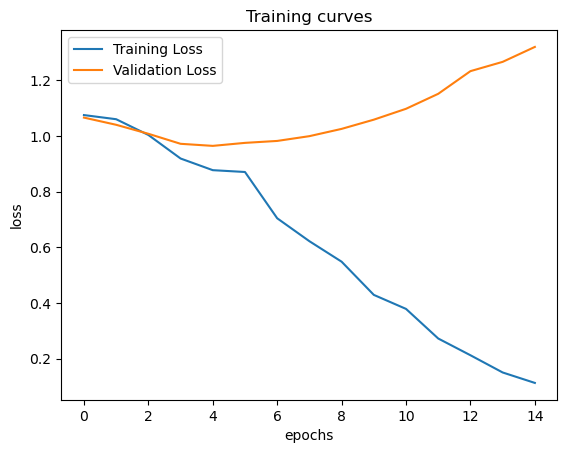

In [27]:
training_curves(train_losses, dev_losses)

### 4. Evaluation

Predict

In [28]:
def predict(model, test_loader):
    model.eval()
    gold_labs = []  # gold labels to return
    pred_labs = []  # predicted labels to return

    with torch.no_grad():
        for inputs, labels in test_loader:
            output = model(inputs)
            predicted_labels = output.argmax(1)
            
            gold_labs.extend(labels.tolist())
            pred_labs.extend(predicted_labels.tolist())

    return gold_labs, pred_labs

In [29]:
y_true, y_pred = predict(trained_model, test_loader)

evaluate(y_pred, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


==== Error Analysis ====

True=yes (total=276, correct=276, error=0):

True=no (total=169, correct=0, error=169):
   Predicted yes: 169/169 (100.0%)

True=maybe (total=55, correct=0, error=55):
   Predicted yes: 55/55 (100.0%)


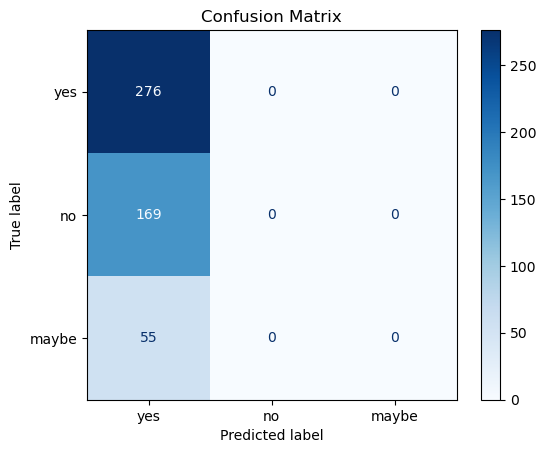

In [30]:
plot_confusion_matrix(y_true, y_pred)

### 5. With Class Weighting

In [31]:
counts = np.bincount(train_labels)
counts_tensor = torch.FloatTensor(counts)
weights = 1.0 / counts_tensor
weights = weights / weights.sum() * 3 # normalization

print(f"counts: {counts} \nWeights: {weights}")

counts: [249 152  49] 
Weights: tensor([0.3886, 0.6366, 1.9748])


In [32]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM)
trained_model_balanced, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model, 
                                                    train_loader,
                                                    dev_loader, 
                                                    learning_rate,
                                                    weights)


All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.0952 Training Accuracy: 33.7778%
Epoch: 1/15 Validation Loss: 1.1017 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1017)
Epoch: 2/15 Training Loss: 1.0965 Training Accuracy: 33.7778%
Epoch: 2/15 Validation Loss: 1.1015 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1015)
Epoch: 3/15 Training Loss: 1.0821 Training Accuracy: 38.0000%
Epoch: 3/15 Validation Loss: 1.0994 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.0994)
Epoch: 4/15 Training Loss: 1.0484 Training Accuracy: 71.3333%
Epoch: 4/15 Validation Loss: 1.0968 Validation Accuracy: 48.0000%
Best model saved (validation_loss=1.0968)
Epoch: 5/15 Training Loss: 1.0061 Training Accuracy: 93.5556%
Epoch: 5/15 Validation Loss: 1.0949 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0949)
Epoch: 6/15 Training Loss: 0.9380 Training Accuracy: 97.7778%
Epoch:

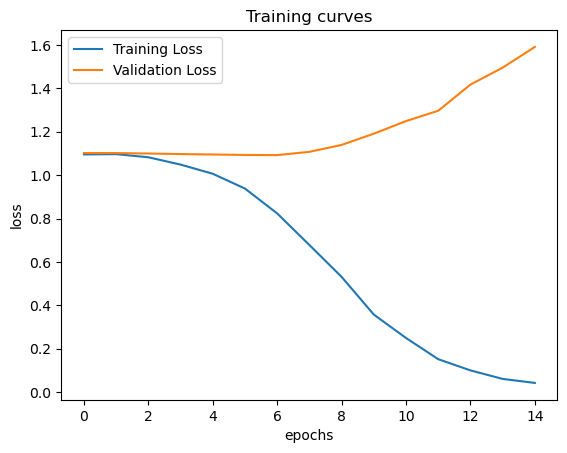

In [33]:
training_curves(train_losses, dev_losses)

In [34]:
y_true, y_pred_balanced = predict(trained_model_balanced, test_loader)

evaluate(y_pred_balanced, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5380  Macro-F1: 0.3101
              precision    recall  f1-score   support

         yes       0.56      0.91      0.70       276
          no       0.46      0.09      0.16       169
       maybe       0.14      0.05      0.08        55

    accuracy                           0.54       500
   macro avg       0.39      0.35      0.31       500
weighted avg       0.48      0.54      0.45       500



==== Error Analysis ====

True=yes (total=276, correct=250, error=26):
   Predicted no: 16/276 (5.8%)
   Predicted maybe: 10/276 (3.6%)

True=no (total=169, correct=16, error=153):
   Predicted yes: 144/169 (85.2%)
   Predicted maybe: 9/169 (5.3%)

True=maybe (total=55, correct=3, error=52):
   Predicted yes: 49/55 (89.1%)
   Predicted no: 3/55 (5.5%)


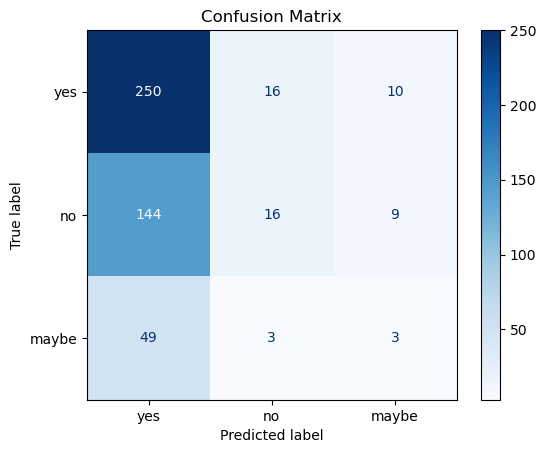

In [35]:
plot_confusion_matrix(y_true, y_pred_balanced)

### 6. With Dimensionality Reduction

In [48]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM_LSA)
trained_model_balanced_lsa, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model,
                                                    train_loader_lsa,
                                                    dev_loader_lsa, 
                                                    learning_rate,
                                                    weights)

All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.0998 Training Accuracy: 33.5556%
Epoch: 1/15 Validation Loss: 1.1007 Validation Accuracy: 34.0000%
Best model saved (validation_loss=1.1007)
Epoch: 2/15 Training Loss: 1.0946 Training Accuracy: 36.4444%
Epoch: 2/15 Validation Loss: 1.1008 Validation Accuracy: 34.0000%
Epoch: 3/15 Training Loss: 1.0919 Training Accuracy: 41.1111%
Epoch: 3/15 Validation Loss: 1.1016 Validation Accuracy: 34.0000%
Epoch: 4/15 Training Loss: 1.0891 Training Accuracy: 43.5556%
Epoch: 4/15 Validation Loss: 1.1021 Validation Accuracy: 34.0000%
Epoch: 5/15 Training Loss: 1.0823 Training Accuracy: 55.5556%
Epoch: 5/15 Validation Loss: 1.1029 Validation Accuracy: 52.0000%
Epoch: 6/15 Training Loss: 1.0831 Training Accuracy: 56.8889%
Epoch: 6/15 Validation Loss: 1.1039 Validation Accuracy: 54.0000%
Epoch: 7/15 Training Loss: 1.0765 Training Accuracy: 57.3333%
Epoch: 7/15 Validation Loss: 1.1035 Validation

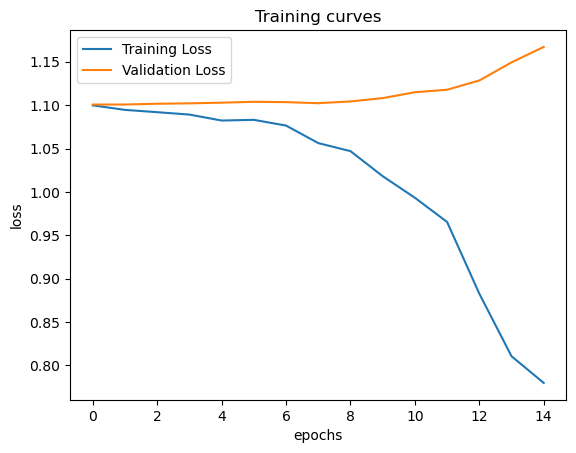

In [49]:
training_curves(train_losses, dev_losses)

In [50]:
y_true, y_pred_balanced_lsa = predict(trained_model_balanced_lsa, test_loader_lsa)

evaluate(y_pred_balanced_lsa, y_true, "Test_set")


── Test_set ──
Accuracy: 0.3380  Macro-F1: 0.1684
              precision    recall  f1-score   support

         yes       0.00      0.00      0.00       276
          no       0.34      1.00      0.51       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.34       500
   macro avg       0.11      0.33      0.17       500
weighted avg       0.11      0.34      0.17       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


==== Error Analysis ====

True=yes (total=276, correct=0, error=276):
   Predicted no: 276/276 (100.0%)

True=no (total=169, correct=169, error=0):

True=maybe (total=55, correct=0, error=55):
   Predicted no: 55/55 (100.0%)


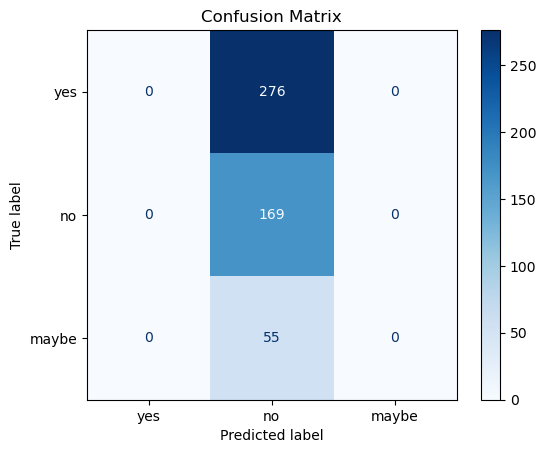

In [54]:
plot_confusion_matrix(y_true, y_pred_balanced_lsa)

In [64]:
get_errors_by_type(data, y_true, y_pred_balanced_lsa, true_class="yes", pred_class="no", n=3)
#get_errors_by_type(data, y_true, y_pred_balanced_lsa, true_class="maybe", pred_class="yes", n=3)

True=yes  Predicted=no  (total 276 errors, showing 3)
  Question: Is anorectal endosonography valuable in dyschesia?
  Context: ['Dyschesia can be provoked by inappropriate defecation movements. The aim of this prospective study was to demonstrate dysfunction of the anal sphincter and/or the musculus (m.) puborectalis in patients with dyschesia using anorectal endosonography.', 'Twenty consecutive patients with a medical history of dyschesia and a control group of 20 healthy subjects underwent linear anorectal endosonography (Toshiba models IUV 5060 and PVL-625 RT). In both groups, the dimensions of the anal sphincter and the m. puborectalis were measured at rest, and during voluntary squeezing and straining. Statistical analysis was performed within and between the two groups.', 'The anal sphincter became paradoxically shorter and/or thicker during straining (versus the resting state) in 85% of patients but in only 35% of control subjects. Changes in sphincter length were statisticall

In [65]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM_LSA)
trained_model_lsa, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model,
                                                    train_loader_lsa,
                                                    dev_loader_lsa, 
                                                    learning_rate)

All seeds set to 11
Epoch: 1/15 Training Loss: 1.0844 Training Accuracy: 36.6667%
Epoch: 1/15 Validation Loss: 1.0736 Validation Accuracy: 36.0000%
Best model saved (validation_loss=1.0736)
Epoch: 2/15 Training Loss: 1.0604 Training Accuracy: 52.6667%
Epoch: 2/15 Validation Loss: 1.0520 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0520)
Epoch: 3/15 Training Loss: 1.0300 Training Accuracy: 55.1111%
Epoch: 3/15 Validation Loss: 1.0288 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0288)
Epoch: 4/15 Training Loss: 0.9807 Training Accuracy: 55.3333%
Epoch: 4/15 Validation Loss: 1.0034 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0034)
Epoch: 5/15 Training Loss: 0.9413 Training Accuracy: 55.3333%
Epoch: 5/15 Validation Loss: 0.9780 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9780)
Epoch: 6/15 Training Loss: 0.9622 Training Accuracy: 55.3333%
Epoch: 6/15 Validation Loss: 0.9617 Validation Accuracy: 54.0000%
Be

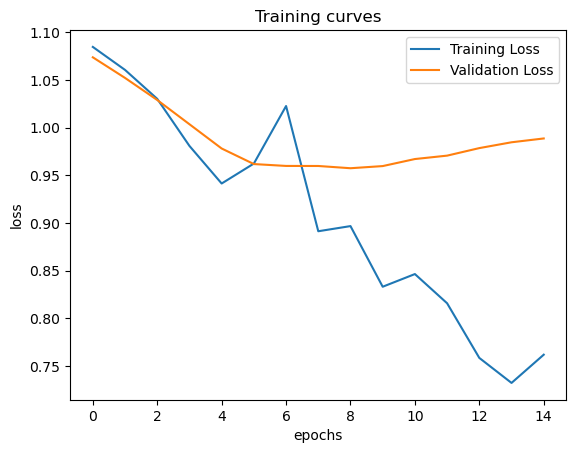

In [66]:
training_curves(train_losses, dev_losses)

In [67]:
y_true, y_pred_lsa = predict(trained_model_lsa, test_loader_lsa)

evaluate(y_pred_lsa, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


==== Error Analysis ====

True=yes (total=276, correct=276, error=0):

True=no (total=169, correct=0, error=169):
   Predicted yes: 169/169 (100.0%)

True=maybe (total=55, correct=0, error=55):
   Predicted yes: 55/55 (100.0%)


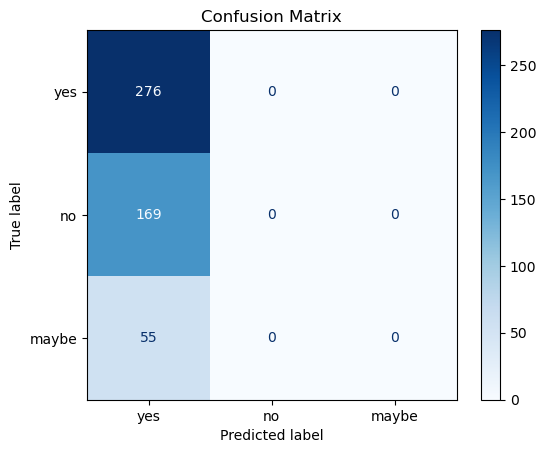

In [68]:
plot_confusion_matrix(y_true, y_pred_lsa)